In [45]:
import duckdb
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

con = duckdb.connect("../Data/processed/project.duckdb")

trades_with_trader_df = con.execute("SELECT * FROM trades_with_trader WHERE traderId IS NOT NULL").fetchdf()
rebuilt_account_summary = pd.read_csv("../Data/processed/rebuilt_account_summary.csv")


DATA : The data being used is essentially the masterdataset stored as a table in project.duckdb as trades_with traders. 

- We are treating email as a primary key. As in, an emailID means a unique trader. According to PDPA laws, we cannot keep the email, tele ID column and therefore we created a "traderID" column, which is a unique identifier made by hashing the emailID (creating a unique serial number by hashing the email). 
- We added a campaignID column also, which just points to which campaign a user was a part of. We added this to both trades and users dataset files
- Then we joined these two to create trades_with_trader, which includes all columns of trades + traderID. We did this by joining users and trades on the condition that the campaign ID and account ID both were same. (in a given campaign, the accountID will belong to one person only, even though across campaigns the accountID is recycled)

# Data quality checks

In [2]:
print("\nTotal trades:", len(trades_with_trader_df))
print("Distinct traders:", trades_with_trader_df["traderId"].nunique())
print("\nNulls per column:\n", trades_with_trader_df.isna().sum())
print("\nDuplicate rows:", trades_with_trader_df.duplicated().sum())



Total trades: 46376
Distinct traders: 3550

Nulls per column:
 accountId            0
closeTradeId         0
positionId           0
closeOrderId         0
openOrderId          0
durationSec          0
openDateTime         0
closeDateTime        0
profit               0
reverseProfit        0
netProfit            0
commission           0
amount               0
openPrice            0
closePrice           0
slPrice          24546
tpPrice          20886
side                 0
userGroupId          0
filename             0
campaignId           0
has_SL               0
has_TP               0
traderId             0
dtype: int64

Duplicate rows: 0


In [3]:
#Range sanity check
print(trades_with_trader_df[["durationSec", "amount", "netProfit"]].describe())

        durationSec        amount     netProfit
count  46376.000000  46376.000000  46376.000000
mean    1413.167177      0.183879     -6.662067
std     3925.868104      0.144554    106.069356
min        0.000000      0.010000   -944.100000
25%       78.000000      0.090000    -51.700000
50%      272.000000      0.120000     -0.640000
75%      995.000000      0.250000     45.400000
max    79210.000000      0.630000    680.640000


Nothing here looks broken: it's confirming the data is usable before moving on to the actual hypothesis tests.

# Trader level profiling

In [4]:
trades_per_trader = trades_with_trader_df.groupby("traderId").size()
print("\nTrades per trader — mean:", round(trades_per_trader.mean(), 1),
      "median:", trades_per_trader.median(), "std:", round(trades_per_trader.std(), 1))

campaigns_per_trader = trades_with_trader_df.groupby("traderId")["campaignId"].nunique()
print("\nTraders in >1 campaign:", (campaigns_per_trader > 1).sum(), "of", len(campaigns_per_trader))

print("\nWinner/loser split:", rebuilt_account_summary["outcome"].value_counts().to_dict())



Trades per trader — mean: 13.1 median: 5.0 std: 26.7

Traders in >1 campaign: 1313 of 3550

Winner/loser split: {'loser': 2211, 'winner': 1339}


Median is only 5 — the typical trader made just 5 trades.

Mean is 13.1 — more than double the median.

Std is 26.7 — larger than the mean.

When mean > median and std > mean like this, it means a small number of very active traders (hundreds of trades each, pulling the average way up) are dragging the mean far above what a typical trader actually did. So "13.1 trades on average" is misleading as a description of a normal trader — **5 trades (the median) is a much better representation of typical behavior**, and the high std is telling you there's a long tail of a few outlier traders trading way more than everyone else.

Approximately 37% of traders participated in more than 1 campaign

IMP : Winners = positive net profit ; Losers = negative net profit

# EDA

In [5]:
#Test 1: Median holding time, winner vs loser
hold_by_trader = trades_with_trader_df.groupby("traderId")["durationSec"].median().reset_index(name="median_hold")
rebuilt_account_summary = rebuilt_account_summary.merge(hold_by_trader, on="traderId", how="left")
w = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="winner"]["median_hold"].dropna()
l = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="loser"]["median_hold"].dropna()
u1, p1 = stats.mannwhitneyu(w, l)
print(f"\n[1] Holding time — winner median: {w.median():.1f}s, loser: {l.median():.1f}s, p={p1:.4f}")



[1] Holding time — winner median: 610.0s, loser: 480.0s, p=0.0009


The results are significant, winners hold longer

In [6]:
#Test 2: Commission vs directional loss

total_comm = trades_with_trader_df["commission"].sum()
total_dir = trades_with_trader_df["profit"].sum()
print(f"[2] Commission: {total_comm:.2f}, Directional: {total_dir:.2f}, Ratio: {abs(total_comm/total_dir):.1f}x")

[2] Commission: -298472.87, Directional: -10487.16, Ratio: 28.5x


In [7]:
#Test 3: No-SL 50% threshold split

nosl_pct = trades_with_trader_df.groupby("traderId")["has_SL"].apply(lambda x: 100*(~x).mean()).reset_index(name="no_sl_pct_check")
rebuilt_account_summary = rebuilt_account_summary.merge(nosl_pct, on="traderId", how="left")
high = rebuilt_account_summary[rebuilt_account_summary["no_sl_pct_check"] >= 50]["total_netProfit"]
low = rebuilt_account_summary[rebuilt_account_summary["no_sl_pct_check"] < 50]["total_netProfit"]
t3, p3 = stats.ttest_ind(high, low, equal_var=False)
print(f"[3] No-SL split — high avg profit: {high.mean():.2f}, low: {low.mean():.2f}, p={p3:.4f}")

[3] No-SL split — high avg profit: -94.78, low: -75.95, p=0.1716


The results are not significant

In [8]:
#Test 4: Position size after loss vs after win

def get_after_loss_win_sizes(df, id_col):
    df = df.sort_values([id_col, "openDateTime"]).copy()
    df["prev_netProfit"] = df.groupby(id_col)["netProfit"].shift(1)
    df["prev_outcome"] = df["prev_netProfit"].apply(lambda x: "after_loss" if x < 0 else ("after_win" if x >= 0 else None))
    sizes = df.groupby([id_col, "prev_outcome"])["amount"].mean().unstack()
    sizes.columns = ["after_loss", "after_win"]
    return sizes.dropna()

sizes = get_after_loss_win_sizes(trades_with_trader_df, "traderId")
w4, p4 = stats.wilcoxon(sizes["after_loss"], sizes["after_win"])
print(f"[4] Size after loss: {sizes['after_loss'].median():.3f}, after win: {sizes['after_win'].median():.3f}, p={p4:.4f} (n={len(sizes)})")


[4] Size after loss: 0.159, after win: 0.150, p=0.0033 (n=2043)


The results are significant but we must tread lighty here because when this test was run on the masterdataset as accountID as the unique identifier, the results were actually the opposite of this. 

Prisha's take on this: We should trust this traderId-based result over the earlier accountId-based one, since accountId recycling across campaigns could wrongly merge/split traders' sequences and corrupt the after_loss/after_win pairing.

In [9]:
#Test 5: Max drawdown, winner vs loser

def fast_max_drawdown(df, id_col):
    df = df.sort_values([id_col, "openDateTime"]).copy()
    df["equity"] = df.groupby(id_col)["netProfit"].cumsum()
    df["running_max"] = df.groupby(id_col)["equity"].cummax()
    df["drawdown"] = df["equity"] - df["running_max"]
    return df.groupby(id_col)["drawdown"].min().reset_index(name="max_drawdown")

dd = fast_max_drawdown(trades_with_trader_df, "traderId")
rebuilt_account_summary = rebuilt_account_summary.merge(dd, on="traderId", how="left", suffixes=("", "_dup"))
w5 = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="winner"]["max_drawdown"].dropna()
l5 = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="loser"]["max_drawdown"].dropna()
u5, p5 = stats.mannwhitneyu(w5, l5)
print(f"[5] Max drawdown — winner: {w5.median():.1f}, loser: {l5.median():.1f}, p={p5:.4f}")



[5] Max drawdown — winner: -30.0, loser: -230.9, p=0.0000


Strong result, this helps seperate winners from losers 

-------------------------------------------------------------------------------------------------------------

# ADDITIONAL EDA ( WE CAN ADD CODE HERE AND CLEAN UP THIS PART LATER)

------------------------------------------------------------------------------------------------------------

## EDA FROM DEVANSHI

We want to check what the trader CROWD does in an hour and if it may predict what happens in the next hour

In [10]:
#all the trading details aggregated wrt whats happening by the hour
flow_by_hour = con.execute("""
    SELECT 
        campaignId,
        DATE_TRUNC('hour', openDateTime) AS hour_bucket,
        SUM(CASE WHEN side='BUY' THEN amount ELSE 0 END) AS buy_volume,
        SUM(CASE WHEN side='SELL' THEN amount ELSE 0 END) AS sell_volume,
        SUM(CASE WHEN side='BUY' THEN amount ELSE -amount END) AS net_flow,
        COUNT(*) AS n_trades,
        AVG(openPrice) AS avg_price,
        SUM(CASE WHEN NOT has_SL THEN 1 ELSE 0 END) AS n_no_sl,
        AVG(netProfit) AS avg_netProfit
    FROM trades_with_trader
    GROUP BY campaignId, hour_bucket
    ORDER BY campaignId, hour_bucket
""").fetchdf()

print(flow_by_hour.shape)
print(flow_by_hour.head(10))

(722, 9)
  campaignId               hour_bucket  buy_volume  sell_volume      net_flow  \
0         33 2026-02-24 08:00:00+08:00        0.00         0.04 -4.000000e-02   
1         33 2026-02-24 09:00:00+08:00        1.91         1.85  6.000000e-02   
2         33 2026-02-24 10:00:00+08:00        4.02         4.45 -4.300000e-01   
3         33 2026-02-24 11:00:00+08:00        1.39         2.58 -1.190000e+00   
4         33 2026-02-24 12:00:00+08:00        3.32         3.32  1.491862e-16   
5         33 2026-02-24 13:00:00+08:00        5.00         2.58  2.420000e+00   
6         33 2026-02-24 14:00:00+08:00        7.23         3.14  4.090000e+00   
7         33 2026-02-24 15:00:00+08:00       10.28         3.33  6.950000e+00   
8         33 2026-02-24 16:00:00+08:00        3.59         2.92  6.700000e-01   
9         33 2026-02-24 17:00:00+08:00        2.07         1.03  1.040000e+00   

   n_trades    avg_price  n_no_sl  avg_netProfit  
0         1  5229.600000      0.0     105.880000

In [11]:
# trying to check if the info we have about a CURRENT hour helps predict what may happen in the NEXT hour

#building the next hours price change column ( how much price moved after the current hour)
flow_by_hour = flow_by_hour.sort_values(["campaignId", "hour_bucket"]).reset_index(drop=True)

flow_by_hour["next_price"] = flow_by_hour.groupby("campaignId")["avg_price"].shift(-1)
flow_by_hour["price_change_next_hour"] = flow_by_hour["next_price"] - flow_by_hour["avg_price"]

#running the lagged correlation scan 
candidate_metrics = ["net_flow", "buy_volume", "sell_volume", "n_trades", "n_no_sl", "avg_netProfit"]

correlations = flow_by_hour[candidate_metrics + ["price_change_next_hour"]].corr()["price_change_next_hour"].drop("price_change_next_hour")

print(correlations.sort_values(key=abs, ascending=False))

net_flow         0.052417
buy_volume       0.043336
n_trades         0.035736
n_no_sl          0.019569
sell_volume      0.009554
avg_netProfit    0.006337
Name: price_change_next_hour, dtype: float64


this is a weak result

In [12]:
flow_by_hour["net_flow_pct"] = flow_by_hour["net_flow"] / (flow_by_hour["buy_volume"] + flow_by_hour["sell_volume"])
correlation_pct = flow_by_hour[["net_flow_pct", "price_change_next_hour"]].corr()
print(correlation_pct)

                        net_flow_pct  price_change_next_hour
net_flow_pct                 1.00000                 0.10943
price_change_next_hour       0.10943                 1.00000


In [13]:
for lag in [1, 2, 3, 4]:
    flow_by_hour[f"price_change_lag{lag}"] = (
        flow_by_hour.groupby("campaignId")["avg_price"].shift(-lag) - flow_by_hour["avg_price"]
    )
    corr = flow_by_hour["net_flow"].corr(flow_by_hour[f"price_change_lag{lag}"])
    print(f"Lag {lag} hour(s): correlation = {corr:.4f}")

Lag 1 hour(s): correlation = 0.0524
Lag 2 hour(s): correlation = 0.0241
Lag 3 hour(s): correlation = 0.0240
Lag 4 hour(s): correlation = 0.0103


this is obvious, the weak correlation keeps becoming less and less as time passes

In [14]:
extreme_buy = flow_by_hour[flow_by_hour["net_flow"] > flow_by_hour["net_flow"].quantile(0.9)]
extreme_sell = flow_by_hour[flow_by_hour["net_flow"] < flow_by_hour["net_flow"].quantile(0.1)]

print("After extreme net-buying hours, avg next-hour price change:", extreme_buy["price_change_next_hour"].mean())
print("After extreme net-selling hours, avg next-hour price change:", extreme_sell["price_change_next_hour"].mean())

After extreme net-buying hours, avg next-hour price change: 0.3639303870228143
After extreme net-selling hours, avg next-hour price change: -2.668097649834517


This may be a obvious result but gold prices moved a lot over 4.5 months(during all the campaigns) so we need to check if extreme buying predicts a move beyond what the general trend would already predict.Simplest version: detrend by looking at the price change relative to the campaign's own average movement that day, not the raw price change.

In [15]:
# subtract each campaign's own average hourly price change, to remove the trend
flow_by_hour["campaign_avg_change"] = flow_by_hour.groupby("campaignId")["price_change_next_hour"].transform("mean")
flow_by_hour["detrended_change"] = flow_by_hour["price_change_next_hour"] - flow_by_hour["campaign_avg_change"]

extreme_buy = flow_by_hour[flow_by_hour["net_flow_pct"] > flow_by_hour["net_flow_pct"].quantile(0.9)]
extreme_sell = flow_by_hour[flow_by_hour["net_flow_pct"] < flow_by_hour["net_flow_pct"].quantile(0.1)]

print("Extreme buy, detrended next-hour change:", extreme_buy["detrended_change"].mean())
print("Extreme sell, detrended next-hour change:", extreme_sell["detrended_change"].mean())

Extreme buy, detrended next-hour change: 3.6670206887557986
Extreme sell, detrended next-hour change: -2.550320908006554


In [16]:
flow_by_hour = flow_by_hour.sort_values(["campaignId", "hour_bucket"]).reset_index(drop=True)

behavior_cols = ["net_flow_pct", "n_trades", "n_no_sl", "avg_netProfit", "buy_volume", "sell_volume"]

for col in behavior_cols:
    flow_by_hour[f"next_{col}"] = flow_by_hour.groupby("campaignId")[col].shift(-1)

# also useful: no-SL as a RATE, not raw count, so it's comparable across busier/quieter hours
flow_by_hour["no_sl_rate"] = flow_by_hour["n_no_sl"] / flow_by_hour["n_trades"]
flow_by_hour["next_no_sl_rate"] = flow_by_hour.groupby("campaignId")["no_sl_rate"].shift(-1)

this_hour = ["net_flow_pct", "n_trades", "no_sl_rate", "avg_netProfit"]
next_hour = ["next_net_flow_pct", "next_n_trades", "next_no_sl_rate", "next_avg_netProfit"]

corr_matrix = flow_by_hour[this_hour + next_hour].corr().loc[this_hour, next_hour]
print(corr_matrix.round(3))



               next_net_flow_pct  next_n_trades  next_no_sl_rate  \
net_flow_pct               0.055         -0.021           -0.047   
n_trades                  -0.036          0.784            0.056   
no_sl_rate                 0.016          0.085            0.313   
avg_netProfit              0.015          0.070            0.127   

               next_avg_netProfit  
net_flow_pct                0.137  
n_trades                    0.032  
no_sl_rate                  0.009  
avg_netProfit               0.024  


1. this just shows that high number of trades are just followed by high number of trades in the next hour (0.763) 
2. but also that no sl is maybe followed by no sl in the next hour 

lets look at the no sl thing 

In [17]:
# among NO-SL trades only, look at the distribution of losses
no_sl_losses = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < 0)
]["netProfit"]

print(no_sl_losses.describe())
print("\nWhat % of no-SL losses are 'small/disciplined' (say, better than -50) vs 'catastrophic' (worse than -300)?")
print("Disciplined-ish:", (no_sl_losses > -50).mean())
print("Catastrophic:", (no_sl_losses < -300).mean())

count    11323.000000
mean       -91.286328
std        103.795039
min       -944.100000
25%       -135.600000
50%        -51.960000
75%        -14.105000
max         -0.010000
Name: netProfit, dtype: float64

What % of no-SL losses are 'small/disciplined' (say, better than -50) vs 'catastrophic' (worse than -300)?
Disciplined-ish: 0.48988783891194915
Catastrophic: 0.04936854190585534


In [18]:
catastrophic = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < -300)
]

disciplined = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < 0) & (trades_with_trader_df["netProfit"] > -50)
]

print("Catastrophic trades — median duration:", catastrophic["durationSec"].median(), 
      "median size:", catastrophic["amount"].median())
print("Disciplined trades — median duration:", disciplined["durationSec"].median(), 
      "median size:", disciplined["amount"].median())

Catastrophic trades — median duration: 1267.0 median size: 0.3
Disciplined trades — median duration: 63.0 median size: 0.1


In [19]:
no_sl_trades = trades_with_trader_df[~trades_with_trader_df["has_SL"]].copy()
no_sl_trades["is_catastrophic"] = no_sl_trades["netProfit"] < -300

# check: among trades that are STILL OPEN past 5 minutes (300 sec) with above-median size,
# what fraction eventually go catastrophic, vs trades that don't meet that criteria?
median_size = no_sl_trades["amount"].median()

no_sl_trades["flagged"] = (no_sl_trades["durationSec"] > 300) & (no_sl_trades["amount"] > median_size)

print(no_sl_trades.groupby("flagged")["is_catastrophic"].mean())
print(no_sl_trades["flagged"].value_counts())

flagged
False    0.015265
True     0.098732
Name: is_catastrophic, dtype: float64
flagged
False    22338
True      2208
Name: count, dtype: int64


In [20]:
catastrophic = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < -300)
]

disciplined = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < 0) & (trades_with_trader_df["netProfit"] > -50)
]

print("Catastrophic trades — avg reverseProfit:", catastrophic["reverseProfit"].mean())
print("Disciplined trades — avg reverseProfit:", disciplined["reverseProfit"].mean())

# also worth checking: reverseProfit specifically for the FLAGGED group vs non-flagged
print("\nFlagged trades — avg reverseProfit:", no_sl_trades[no_sl_trades["flagged"]]["reverseProfit"].mean())
print("Non-flagged trades — avg reverseProfit:", no_sl_trades[~no_sl_trades["flagged"]]["reverseProfit"].mean())

Catastrophic trades — avg reverseProfit: 380.3320035778176
Disciplined trades — avg reverseProfit: 10.441956913647017

Flagged trades — avg reverseProfit: 23.03688405797101
Non-flagged trades — avg reverseProfit: -1.1453796221685022


## EDA FROM PRISHA

### Viewing project.duckdb, trades_with_trader, trades_campaign_features directly

In [21]:
# project.duckdb: list tables and preview one
print(con.execute("SHOW TABLES").fetchdf())
con.execute("SELECT * FROM trades_with_trader LIMIT 5").fetchdf()

                       name
0                    trades
1  trades_campaign_features
2        trades_with_trader
3                     users


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,closePrice,slPrice,tpPrice,side,userGroupId,filename,campaignId,has_SL,has_TP,traderId
0,D#1702379,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,19,2026-02-24 09:02:19+08:00,2026-02-24 09:02:38+08:00,0.47,-0.54,...,5206.14,NaN,NaN,BUY,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,9610a0dfe436
1,D#1645651,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,29,2026-02-24 09:02:15+08:00,2026-02-24 09:02:44+08:00,2.24,-2.31,...,5207.23,NaN,NaN,SELL,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,6592ab90514d
2,D#1670922,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,38,2026-02-24 09:07:03+08:00,2026-02-24 09:07:41+08:00,1.00,-1.07,...,5200.16,NaN,NaN,SELL,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,2baef295c655
3,D#1702617,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,208,2026-02-24 09:06:23+08:00,2026-02-24 09:09:51+08:00,5.52,-5.73,...,5206.58,NaN,NaN,BUY,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,45473583265f
4,D#1670952,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,109,2026-02-24 09:09:51+08:00,2026-02-24 09:11:40+08:00,61.60,-62.30,...,5200.67,NaN,NaN,SELL,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,d3d1abf7f5c0


In [22]:
# project.duckdb: list tables and preview one
print(con.execute("SHOW TABLES").fetchdf())
con.execute("SELECT * FROM trades_campaign_features LIMIT 5").fetchdf()

                       name
0                    trades
1  trades_campaign_features
2        trades_with_trader
3                     users


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,campaignId,has_SL,has_TP,traderId,trade_seq_in_campaign,equity,running_peak,drawdown,streak,reentry_gap_sec
0,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,36,2026-03-03 09:55:53+08:00,2026-03-03 09:56:29+08:00,20.80,-21.50,...,34,False,False,00094c908d31,1.0,5017.30,5017.30,0.00,1.0,NaN
1,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,240,2026-03-03 09:59:46+08:00,2026-03-03 10:03:46+08:00,32.70,-33.05,...,34,False,True,00094c908d31,2.0,5048.24,5048.24,0.00,2.0,197.0
2,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,1978,2026-03-03 13:34:39+08:00,2026-03-03 14:07:37+08:00,-189.40,189.05,...,34,True,True,00094c908d31,3.0,4857.08,5048.24,-191.16,-1.0,12653.0
3,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,16,2026-03-03 14:11:27+08:00,2026-03-03 14:11:43+08:00,3.90,-4.25,...,34,False,False,00094c908d31,4.0,4859.22,5048.24,-189.02,1.0,230.0
4,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,5,2026-03-03 14:11:54+08:00,2026-03-03 14:11:59+08:00,5.25,-5.60,...,34,False,False,00094c908d31,5.0,4862.71,5048.24,-185.53,2.0,11.0


### Campaign-aware features (viewing trades_campaign_features)

Each campaign starts from a fresh $5000 account, so equity/peak/streak/re-entry gap need to reset at each (traderId, campaignId) boundary rather than carrying over across a trader's whole history. 
This section loads a new table built by `Scripts/latest_master_ds.py`, without changing anything in the sections above.

New columns, computed per trader per campaign, in time order:
- `trade_seq_in_campaign` — trade number within that campaign, restarting at 1
- `equity` — running balance, starting at $5000 each campaign
- `running_peak` — highest equity reached so far that campaign
- `drawdown` — equity minus running_peak (always ≤ 0)
- `streak` — signed win/loss streak (+2 = 2 wins in a row, -3 = 3 losses in a row), resets each campaign
- `reentry_gap_sec` — seconds since this trader's previous trade closed, within the same campaign only (NULL on each campaign's first trade)

In [23]:
trades_campaign_features_df = con.execute(
    "SELECT * FROM trades_campaign_features WHERE traderId IS NOT NULL"
).fetchdf()

print("Rows:", len(trades_campaign_features_df))
trades_campaign_features_df[
    ["traderId", "campaignId", "trade_seq_in_campaign", "netProfit",
     "equity", "running_peak", "drawdown", "streak", "reentry_gap_sec"]
].head(10)

Rows: 46376


,traderId,campaignId,trade_seq_in_campaign,netProfit,equity,running_peak,drawdown,streak,reentry_gap_sec
0,00094c908d31,34,1.0,17.30,5017.30,5017.30,0.00,1.0,NaN
1,00094c908d31,34,2.0,30.94,5048.24,5048.24,0.00,2.0,197.0
2,00094c908d31,34,3.0,-191.16,4857.08,5048.24,-191.16,-1.0,12653.0
3,00094c908d31,34,4.0,2.14,4859.22,5048.24,-189.02,1.0,230.0
4,00094c908d31,34,5.0,3.49,4862.71,5048.24,-185.53,2.0,11.0
5,00094c908d31,34,6.0,-47.96,4814.75,5048.24,-233.49,-1.0,5.0
6,00094c908d31,35,1.0,23.54,5023.54,5023.54,0.00,1.0,NaN
7,00094c908d31,35,2.0,3.49,5027.03,5027.03,0.00,2.0,1091.0
8,00094c908d31,35,3.0,-247.50,4779.53,5027.03,-247.50,-1.0,1438.0
9,00094c908d31,36,1.0,46.60,5046.60,5046.60,0.00,1.0,NaN


Assumption used below: the 4% max-drawdown rule is treated as **static** (equity < $4,800 at any point in a campaign) rather than trailing from the trader's own peak.


In [24]:
# Test 6: Re-entry Haste Index - faster re-entry after a loss than after a win, tested against campaign-correct max drawdown

tcf = trades_campaign_features_df.copy()
tcf["prev_netProfit"] = tcf.groupby(["traderId", "campaignId"])["netProfit"].shift(1)
tcf["prev_outcome"] = tcf["prev_netProfit"].apply(
    lambda x: "after_loss" if x < 0 else ("after_win" if x >= 0 else None)
)

gap_by_trader = (
    tcf.dropna(subset=["reentry_gap_sec", "prev_outcome"])
    .groupby(["traderId", "prev_outcome"])["reentry_gap_sec"]
    .median()
    .unstack()
    .dropna(subset=["after_loss", "after_win"])
)
gap_by_trader["haste_index"] = gap_by_trader["after_loss"] / gap_by_trader["after_win"]

max_dd_campaign_aware = tcf.groupby("traderId")["drawdown"].min().rename("max_drawdown_campaign_aware")
haste_df = gap_by_trader.join(max_dd_campaign_aware).dropna()

haste_group = haste_df[haste_df["haste_index"] < 1]["max_drawdown_campaign_aware"]
not_haste_group = haste_df[haste_df["haste_index"] >= 1]["max_drawdown_campaign_aware"]

u_haste, p_haste = stats.mannwhitneyu(haste_group, not_haste_group)
print(f"Re-entry Haste Index - haste traders (n={len(haste_group)}) median max drawdown: {haste_group.median():.1f}, "
      f"non-haste (n={len(not_haste_group)}) median: {not_haste_group.median():.1f}, p={p_haste:.4f}")


Re-entry Haste Index - haste traders (n=1351) median max drawdown: -270.4, non-haste (n=595) median: -210.4, p=0.0000


Strong: Confirms the Stage 1 re-entry haste lead: traders who re-enter faster after a loss than after a win (n=1351) show ~29% deeper max drawdown than non-haste traders (n=595), p<0.0001. Strong candidate for a post-loss cool-off intervention.


In [25]:
# Test 7: Tilt Score - does bet size escalate the longer a losing streak runs?
# this is the more specific version of Test 4, looking at longer streaks instead of the previous trade only

import numpy as np

tilt_source = trades_campaign_features_df[trades_campaign_features_df["streak"] < 0].copy()
tilt_source["loss_streak_len"] = tilt_source["streak"].abs().clip(upper=4)  # cap at 4+

def trader_tilt_slope(group):
    if group["loss_streak_len"].nunique() < 3:
        return np.nan
    return np.polyfit(group["loss_streak_len"].values, group["amount"].values, 1)[0]

tilt_slopes = tilt_source.groupby("traderId").apply(trader_tilt_slope).dropna().rename("tilt_slope")

pct_escalating = (tilt_slopes > 0).mean() * 100
w_tilt, p_tilt = stats.wilcoxon(tilt_slopes)
print(f"Tilt Score — {len(tilt_slopes)} traders scored. {pct_escalating:.1f}% show a positive slope "
      f"(bigger bets deeper into a losing streak). Population slope vs. zero: p={p_tilt:.4f}")


Tilt Score — 1173 traders scored. 64.4% show a positive slope (bigger bets deeper into a losing streak). Population slope vs. zero: p=0.0000


Very strong: of 1173 traders with enough losing-streak depth to score (1, 2, 3), 61.6% escalate bet size the longer the streak runs (p<0.0001).

In [26]:
# Test 8: Warning-Response Simulation Score - % of trades placed after equity first crosses the static 4% drawdown line ($4,800), winners vs losers

STATIC_DD_THRESHOLD = 5000 * (1 - 0.04)  # $4800

tcf_sorted = trades_campaign_features_df.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).copy()
tcf_sorted["breached"] = tcf_sorted["equity"] < STATIC_DD_THRESHOLD
tcf_sorted["ever_breached_so_far"] = tcf_sorted.groupby(["traderId", "campaignId"])["breached"].cummax()

warning_response = (
    tcf_sorted.groupby("traderId")["ever_breached_so_far"].mean() * 100
).rename("warning_response_pct").reset_index()

warning_df = warning_response.merge(
    rebuilt_account_summary[["traderId", "outcome"]], on="traderId", how="inner"
)

w_group = warning_df[warning_df["outcome"] == "winner"]["warning_response_pct"]
l_group = warning_df[warning_df["outcome"] == "loser"]["warning_response_pct"]
u_wr, p_wr = stats.mannwhitneyu(w_group, l_group)
print(f"Warning-Response Score — winner median: {w_group.median():.1f}% of trades post-breach, "
      f"loser median: {l_group.median():.1f}%, p={p_wr:.4f}")


Warning-Response Score — winner median: 0.0% of trades post-breach, loser median: 11.1%, p=0.0000


Not sure about the strength of this hypothesis but it shows: a simple $4,800 balance alarm would almost only trigger for eventual losers (11.1% of their trades happen after crossing it, vs 0.0% for the typical winner, p<0.0001) (and with real time left to intervene, not just after the fact.)


In [27]:
# Test 9: Overconfidence Index - bet size after 2+ consecutive wins vs. trader's own baseline

trade_counts = trades_with_trader_df.groupby("traderId").size()
eligible_traders = trade_counts[trade_counts >= 10].index

baseline_amount = trades_campaign_features_df.groupby("traderId")["amount"].median()
after_win_streak_amount = (
    trades_campaign_features_df[trades_campaign_features_df["streak"] >= 2]
    .groupby("traderId")["amount"].median()
)

overconfidence = (after_win_streak_amount / baseline_amount).dropna()
overconfidence = overconfidence[overconfidence.index.isin(eligible_traders)]

w_oc, p_oc = stats.wilcoxon(overconfidence - 1)
print(f"Overconfidence Index — median ratio: {overconfidence.median():.3f} "
      f"(n={len(overconfidence)} traders), vs. baseline of 1.0: p={p_oc:.4f}")


Overconfidence Index — median ratio: 1.000 (n=995 traders), vs. baseline of 1.0: p=0.0003


weak result: most traders don't change their sizing behavior after a win streak at all, but among the minority who do adjust, the adjustment leans toward overconfidence

In [28]:
# Test 10: Friction-to-Edge Ratio per trader - basically a per-trader version of Test 2 instead of the overall ratio

per_trader_totals = trades_with_trader_df.groupby("traderId").agg(
    total_commission=("commission", "sum"),
    total_profit=("profit", "sum"),
    n_trades=("netProfit", "size"),
)
per_trader_totals = per_trader_totals[
    (per_trader_totals["n_trades"] >= 10) & (per_trader_totals["total_profit"] != 0)
]
per_trader_totals["friction_to_edge"] = (
    per_trader_totals["total_commission"].abs() / per_trader_totals["total_profit"].abs()
)

print(f"Friction-to-Edge Ratio per trader (n={len(per_trader_totals)} traders with ≥10 trades)")
print(per_trader_totals["friction_to_edge"].describe())


Friction-to-Edge Ratio per trader (n=1077 traders with ≥10 trades)
count    1077.000000
mean        1.960355
std        10.561593
min         0.023112
25%         0.197339
50%         0.401528
75%         0.969887
max       273.984000
Name: friction_to_edge, dtype: float64


Interesting finding but not sure of relevance: Friction isn't a universal 28.5x tax - the median trader pays only 0.4x their own directional P&L in commission, but a small tail runs up to 273.98x. Friction drag is concentrated in a niche, not spread evenly — a fee-awareness nudge should target that tail, not broadcast to everyone.


## EDA FROM AANYA [METHODS 2 and 3 AS COVERED IN THE DOC]

In [29]:
print(trades_campaign_features_df.columns.tolist())
trades_campaign_features_df.head()

['accountId', 'closeTradeId', 'positionId', 'closeOrderId', 'openOrderId', 'durationSec', 'openDateTime', 'closeDateTime', 'profit', 'reverseProfit', 'netProfit', 'commission', 'amount', 'openPrice', 'closePrice', 'slPrice', 'tpPrice', 'side', 'userGroupId', 'filename', 'campaignId', 'has_SL', 'has_TP', 'traderId', 'trade_seq_in_campaign', 'equity', 'running_peak', 'drawdown', 'streak', 'reentry_gap_sec']


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,campaignId,has_SL,has_TP,traderId,trade_seq_in_campaign,equity,running_peak,drawdown,streak,reentry_gap_sec
0,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,36,2026-03-03 09:55:53+08:00,2026-03-03 09:56:29+08:00,20.80,-21.50,...,34,False,False,00094c908d31,1.0,5017.30,5017.30,0.00,1.0,NaN
1,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,240,2026-03-03 09:59:46+08:00,2026-03-03 10:03:46+08:00,32.70,-33.05,...,34,False,True,00094c908d31,2.0,5048.24,5048.24,0.00,2.0,197.0
2,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,1978,2026-03-03 13:34:39+08:00,2026-03-03 14:07:37+08:00,-189.40,189.05,...,34,True,True,00094c908d31,3.0,4857.08,5048.24,-191.16,-1.0,12653.0
3,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,16,2026-03-03 14:11:27+08:00,2026-03-03 14:11:43+08:00,3.90,-4.25,...,34,False,False,00094c908d31,4.0,4859.22,5048.24,-189.02,1.0,230.0
4,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,5,2026-03-03 14:11:54+08:00,2026-03-03 14:11:59+08:00,5.25,-5.60,...,34,False,False,00094c908d31,5.0,4862.71,5048.24,-185.53,2.0,11.0


In [30]:
import numpy as np


def prepare(df):
    out = df.copy()

    # rev_per_lot — guard against amount == 0
    safe_amount = out["amount"].where(out["amount"] != 0, np.nan)
    out["rev_per_lot"] = out["reverseProfit"] / safe_amount

    # streak split
    out["loss_streak"] = (-out["streak"]).clip(lower=0)
    out["win_streak"] = out["streak"].clip(lower=0)

    # drawdown as % of the $200 (4% of $5000) limit
    out["dd_pct_of_limit"] = (-out["drawdown"]) / 200

    # size vs trader's own expanding avg amount, prior trades only, per (traderId, campaignId)
    ordered = out.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"])
    prior_avg = ordered.groupby(["traderId", "campaignId"])["amount"].transform(
        lambda s: s.shift(1).expanding().mean()
    )
    safe_prior_avg = prior_avg.where(prior_avg != 0, np.nan)
    out["size_vs_running_avg"] = (ordered["amount"] / safe_prior_avg).reindex(out.index)

    # hour of day
    out["hour_of_day"] = pd.to_datetime(out["openDateTime"], errors="coerce").dt.hour

    new_cols = [
        "rev_per_lot", "loss_streak", "win_streak",
        "dd_pct_of_limit", "size_vs_running_avg", "hour_of_day",
    ]
    print("Non-null coverage for derived columns:")
    for col in new_cols:
        print(f"  {col}: {out[col].notna().sum()} / {len(out)}")

    return out


prepared_df = prepare(trades_campaign_features_df)
prepared_df.head()

Non-null coverage for derived columns:
  rev_per_lot: 46376 / 46376
  loss_streak: 46376 / 46376
  win_streak: 46376 / 46376
  dd_pct_of_limit: 46376 / 46376
  size_vs_running_avg: 38248 / 46376
  hour_of_day: 46376 / 46376


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,running_peak,drawdown,streak,reentry_gap_sec,rev_per_lot,loss_streak,win_streak,dd_pct_of_limit,size_vs_running_avg,hour_of_day
0,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,36,2026-03-03 09:55:53+08:00,2026-03-03 09:56:29+08:00,20.80,-21.50,...,5017.30,0.00,1.0,NaN,-215.0,0.0,1.0,-0.00000,NaN,9
1,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,240,2026-03-03 09:59:46+08:00,2026-03-03 10:03:46+08:00,32.70,-33.05,...,5048.24,0.00,2.0,197.0,-661.0,0.0,2.0,-0.00000,0.500000,9
2,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,1978,2026-03-03 13:34:39+08:00,2026-03-03 14:07:37+08:00,-189.40,189.05,...,5048.24,-191.16,-1.0,12653.0,3781.0,1.0,0.0,0.95580,0.666667,13
3,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,16,2026-03-03 14:11:27+08:00,2026-03-03 14:11:43+08:00,3.90,-4.25,...,5048.24,-189.02,1.0,230.0,-85.0,0.0,1.0,0.94510,0.750000,14
4,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,5,2026-03-03 14:11:54+08:00,2026-03-03 14:11:59+08:00,5.25,-5.60,...,5048.24,-185.53,2.0,11.0,-112.0,0.0,2.0,0.92765,0.800000,14


In [43]:
def baseline_and_split(prepared_df):
    # 1. Baseline: reverse everything blindly
    baseline_mean_rev_per_lot = prepared_df["rev_per_lot"].mean()
    baseline_sum_reverseProfit = prepared_df["reverseProfit"].sum()
    baseline_n_trades = len(prepared_df)

    print("BASELINE (reverse everything blindly):")
    print(f"  mean rev_per_lot: {baseline_mean_rev_per_lot:.4f}")
    print(f"  sum reverseProfit: {baseline_sum_reverseProfit:.2f}")
    print(f"  total trades: {baseline_n_trades}")

    # 2. Walk-forward split by campaign, ordered by campaignId
    campaign_order = sorted(prepared_df["campaignId"].unique(), key=int)
    n_campaigns = len(campaign_order)
    n_discovery = round(n_campaigns * 0.7)

    discovery_campaigns = campaign_order[:n_discovery]
    confirmation_campaigns = campaign_order[n_discovery:]

    discovery_df = prepared_df[prepared_df["campaignId"].isin(discovery_campaigns)].copy()
    confirmation_df = prepared_df[prepared_df["campaignId"].isin(confirmation_campaigns)].copy()

    overlap = set(discovery_campaigns) & set(confirmation_campaigns)

    print()
    print("WALK-FORWARD SPLIT (by campaign, ordered by campaignId):")
    print(f"  discovery:    {len(discovery_campaigns)} campaigns, {len(discovery_df)} trades")
    print(f"  confirmation: {len(confirmation_campaigns)} campaigns, {len(confirmation_df)} trades")
    print(f"  campaignId overlap between sets: {len(overlap)} (must be 0) -> {'OK' if len(overlap) == 0 else 'FAILED'}")

    return discovery_df, confirmation_df


discovery_df, confirmation_df = baseline_and_split(prepared_df)

BASELINE (reverse everything blindly):
  mean rev_per_lot: -5.2446
  sum reverseProfit: -49111.46
  total trades: 46376

WALK-FORWARD SPLIT (by campaign, ordered by campaignId):
  discovery:    24 campaigns, 30549 trades
  confirmation: 10 campaigns, 15827 trades
  campaignId overlap between sets: 0 (must be 0) -> OK


In [46]:
def sweep(df, var, bins, baseline_rev_per_lot, labels=None):
    n_missing = df[var].isna().sum()
    work = df.dropna(subset=[var]).copy()
    if n_missing:
        print(f"Dropped {n_missing} rows with NaN in '{var}'")

    # bins=None -> var is already categorical/boolean, use its values directly as buckets
    if bins is None:
        work["_bucket"] = work[var]
    else:
        work["_bucket"] = pd.cut(work[var], bins=bins, labels=labels)

    rows = []
    for bucket, g in work.groupby("_bucket", observed=True):
        n = len(g)
        mean_rpl = g["rev_per_lot"].mean()
        if n >= 2 and g["rev_per_lot"].std(ddof=1) > 0:
            sem = g["rev_per_lot"].std(ddof=1) / np.sqrt(n)
            t_crit = stats.t.ppf(0.975, df=n - 1)
            ci_low, ci_high = mean_rpl - t_crit * sem, mean_rpl + t_crit * sem
        else:
            ci_low, ci_high = np.nan, np.nan
        rows.append({
            "bucket": bucket,
            "n": n,
            "mean_rev_per_lot": mean_rpl,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "sum_reverseProfit": g["reverseProfit"].sum(),
            "median_amount": g["amount"].median(),
        })

    result = pd.DataFrame(rows)
    try:
        result = result.sort_values("bucket").reset_index(drop=True)
    except TypeError:
        result = result.reset_index(drop=True)

    # --- bar chart ---
    x_labels = result["bucket"].astype(str)
    yerr_low = result["mean_rev_per_lot"] - result["ci_low"]
    yerr_high = result["ci_high"] - result["mean_rev_per_lot"]
    colors = np.where(result["ci_low"] > 0, "green", "grey")

    fig, ax = plt.subplots(figsize=(max(6, len(result) * 1.2), 5))
    bars = ax.bar(
        x_labels, result["mean_rev_per_lot"],
        yerr=[yerr_low.fillna(0), yerr_high.fillna(0)],
        capsize=4, color=colors,
    )
    ax.axhline(baseline_rev_per_lot, linestyle="--", color="black", linewidth=1,
               label=f"baseline = {baseline_rev_per_lot:.4f}")
    for bar, n in zip(bars, result["n"]):
        ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
    ax.set_xlabel(var)
    ax.set_ylabel("mean rev_per_lot")
    ax.set_title(f"rev_per_lot by {var}")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # --- flip point ---
    flip = result[result["mean_rev_per_lot"] > 0]
    if len(flip):
        print(f"Flip point: lowest bucket with mean rev_per_lot > 0 is '{flip.iloc[0]['bucket']}'")
    else:
        print("Flip point: no flip")

    return result

Discovery baseline mean rev_per_lot: -9.0465


loss_streak


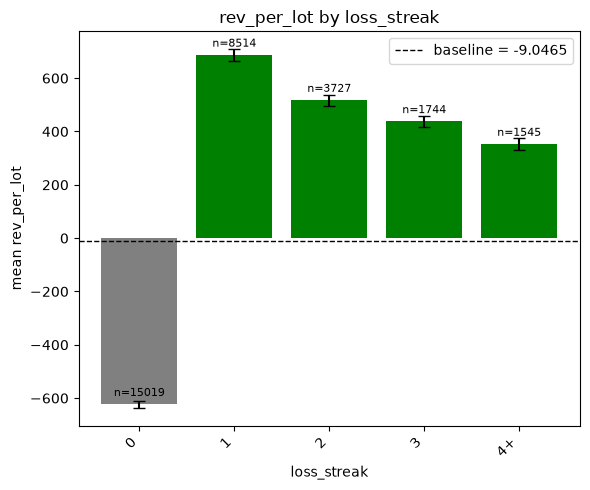

Flip point: lowest bucket with mean rev_per_lot > 0 is '1'

reentry_gap_sec
Dropped 5445 rows with NaN in 'reentry_gap_sec'


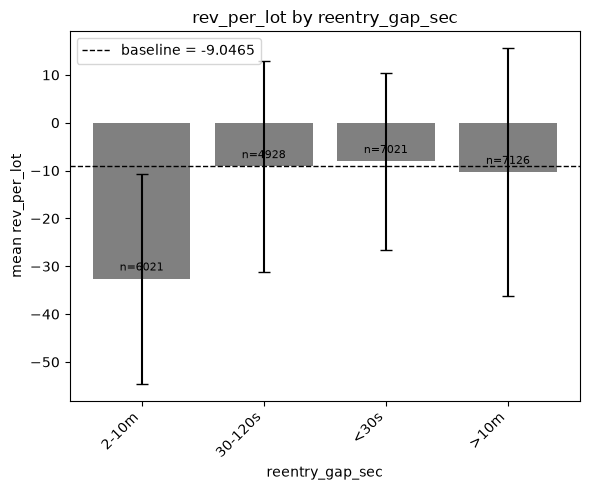

Flip point: no flip

dd_pct_of_limit


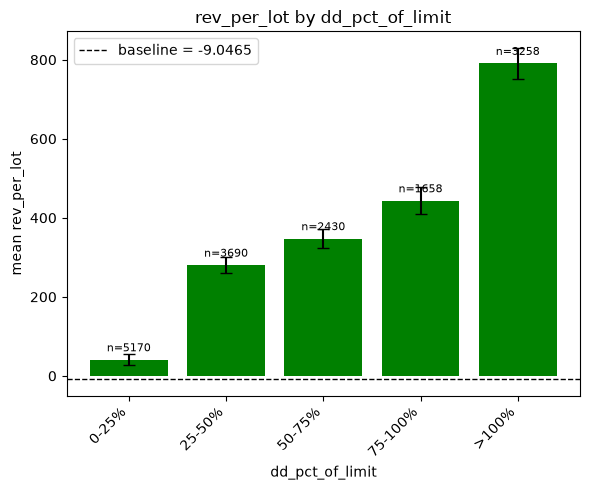

Flip point: lowest bucket with mean rev_per_lot > 0 is '0-25%'

size_vs_running_avg
Dropped 5445 rows with NaN in 'size_vs_running_avg'


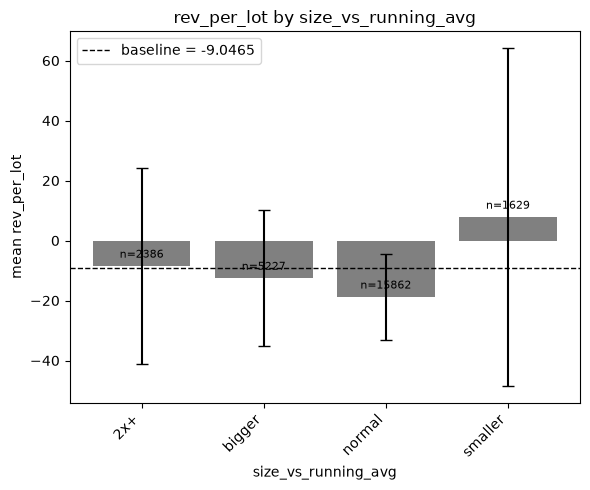

Flip point: lowest bucket with mean rev_per_lot > 0 is 'smaller'

trade_seq_in_campaign


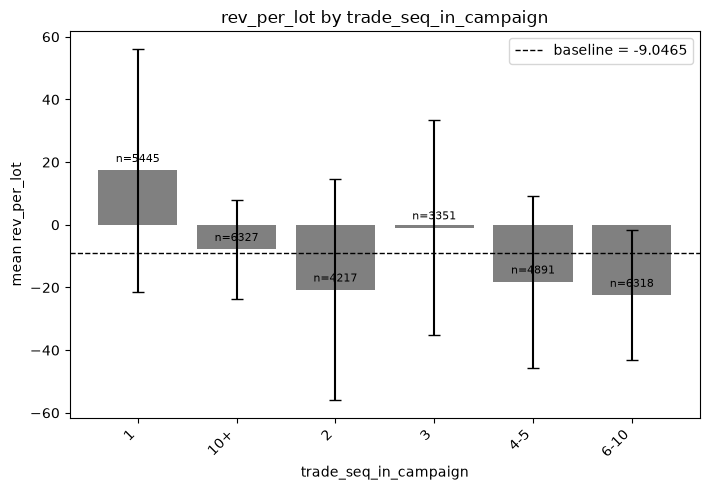

Flip point: lowest bucket with mean rev_per_lot > 0 is '1'

hour_of_day


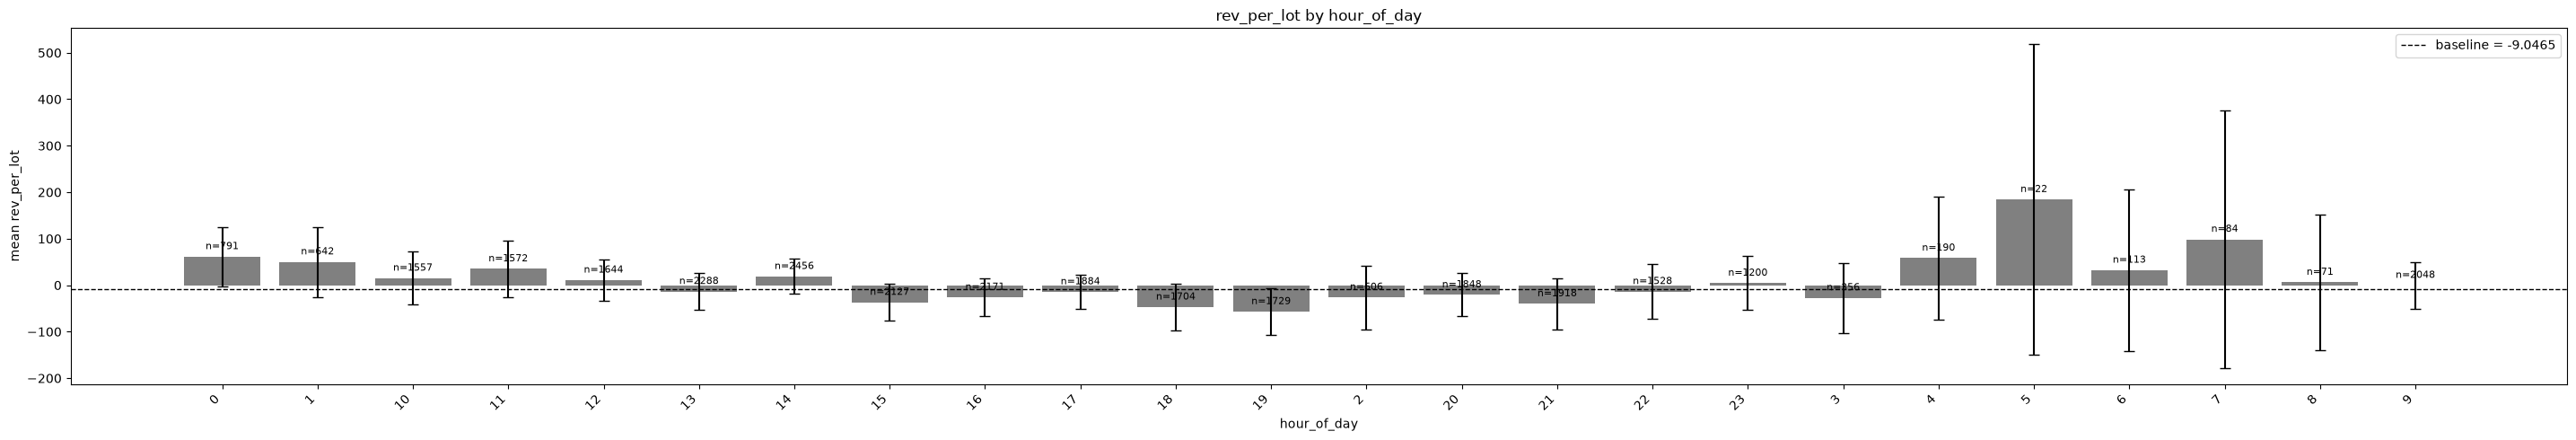

Flip point: lowest bucket with mean rev_per_lot > 0 is '0'

has_SL


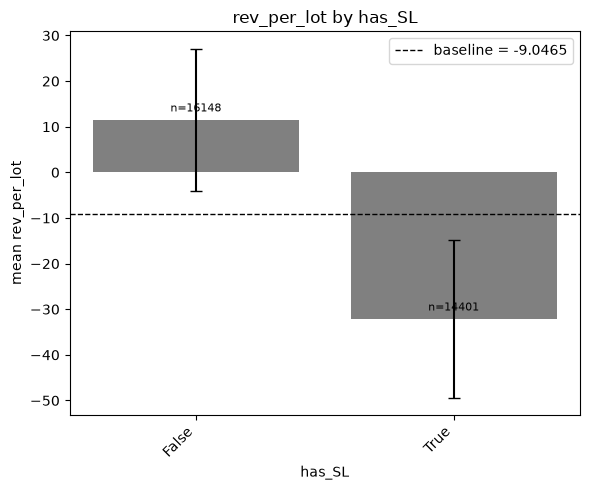

Flip point: lowest bucket with mean rev_per_lot > 0 is 'False'

SUMMARY
             variable flip_point monotonic max_bucket  max_mean_rev_per_lot  max_bucket_n
          loss_streak          1        no          1              686.8220          8514
      reentry_gap_sec    no flip        no       <30s               -8.0635          7021
      dd_pct_of_limit      0-25%       yes      >100%              791.1003          3258
  size_vs_running_avg    smaller        no    smaller                7.8383          1629
trade_seq_in_campaign          1        no          1               17.3893          5445
          hour_of_day          0        no          5              184.3182            22
               has_SL      False       yes      False               11.5205         16148


,variable,flip_point,monotonic,max_bucket,max_mean_rev_per_lot,max_bucket_n
0,loss_streak,1,no,1,686.8220,8514
1,reentry_gap_sec,no flip,no,<30s,-8.0635,7021
2,dd_pct_of_limit,0-25%,yes,>100%,791.1003,3258
3,size_vs_running_avg,smaller,no,smaller,7.8383,1629
4,trade_seq_in_campaign,1,no,1,17.3893,5445
5,hour_of_day,0,no,5,184.3182,22
6,has_SL,False,yes,False,11.5205,16148


In [47]:
discovery_baseline = discovery_df["rev_per_lot"].mean()
print(f"Discovery baseline mean rev_per_lot: {discovery_baseline:.4f}\n")

sweep_specs = [
    ("loss_streak", [-0.5, 0.5, 1.5, 2.5, 3.5, 100], ["0", "1", "2", "3", "4+"]),
    ("reentry_gap_sec", [0, 30, 120, 600, 1e9], ["<30s", "30-120s", "2-10m", ">10m"]),
    ("dd_pct_of_limit", [0, .25, .5, .75, 1.0, 100], ["0-25%", "25-50%", "50-75%", "75-100%", ">100%"]),
    ("size_vs_running_avg", [0, .75, 1.25, 2.0, 100], ["smaller", "normal", "bigger", "2x+"]),
    ("trade_seq_in_campaign", [0, 1, 2, 3, 5, 10, 100], ["1", "2", "3", "4-5", "6-10", "10+"]),
    ("hour_of_day", [h - 0.5 for h in range(25)], [str(h) for h in range(24)]),
    ("has_SL", None, None),
]

sweep_results = {}
for var, bins, labels in sweep_specs:
    print(f"\n{'=' * 60}\n{var}\n{'=' * 60}")
    sweep_results[var] = sweep(discovery_df, var, bins=bins, baseline_rev_per_lot=discovery_baseline, labels=labels)

# --- summary table ---
summary_rows = []
for var, result in sweep_results.items():
    vals = result["mean_rev_per_lot"].values
    monotonic = bool(np.all(np.diff(vals) >= 0) or np.all(np.diff(vals) <= 0)) if len(vals) > 1 else True

    flip = result[result["mean_rev_per_lot"] > 0]
    flip_point = str(flip.iloc[0]["bucket"]) if len(flip) else "no flip"

    max_row = result.loc[result["mean_rev_per_lot"].idxmax()]

    summary_rows.append({
        "variable": var,
        "flip_point": flip_point,
        "monotonic": "yes" if monotonic else "no",
        "max_bucket": str(max_row["bucket"]),
        "max_mean_rev_per_lot": round(max_row["mean_rev_per_lot"], 4),
        "max_bucket_n": int(max_row["n"]),
    })

summary_df = pd.DataFrame(summary_rows)
print(f"\n{'=' * 60}\nSUMMARY\n{'=' * 60}")
print(summary_df.to_string(index=False))
summary_df